## 개요
따릉이 수요를 예측해본다.               
지역구는 은평구로 한정하며 군집화를 통하여 12개의 군집으로 나누었고 그 중에 3개를 뽑아서 진행한다

In [48]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

================================================================== 


01. 파일 로드

In [49]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

==================================================================   


02. 지정된 스테이션으로 통합
- 3개 뽑은 스테이션을 정의함                
- 기준 날짜를 datetime으로 전환
- 전체 이용 시간과 전체 이용 거리가 최소한 5이상인 것들만 추출함
- 시작 대여소가 뽑은 스테이션에 해당하는 데이터만 추출함
- 시작 대여소, datetime, year를 기준으로 그룹화함. 전체 건수의 합, 온도, 습도, 불쾌지수, 강수량, 적설량의 평균으로 집어 넣음

In [50]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-1035', 'ST-454', 'ST-471']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


==================================================================        


03. 전처리 - 1
- datetime을 기준으로 hour, month, weekday, is_weekend, is_holiday 값 추출
- 1시간, 2시간, 3시간, 24시간 전 데이터를 가져옴
- 1시간 전을 기준으로 3시간의 평균 계산
- 시간을 sin과 cos으로 저장
- 달을 sin과 cos으로 저장

In [51]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['month'] = df_hourly['datetime'].dt.month

df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

df_hourly['rush_hour'] = (
    ((df_hourly['hour'] >= 7) & (df_hourly['hour'] <= 9)) |
    ((df_hourly['hour'] >= 17) & (df_hourly['hour'] <= 19))
).astype(int)

# 2. 대여소 ID를 숫자로 변환 (HGB가 대여소별 특징을 알게 함)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# df_hourly['station_idx'] = le.fit_transform(df_hourly['시작_대여소_ID'])
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])



df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)
df_hourly['lag_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(3)
df_hourly['lag_12h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(12)

df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)

df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())

df_hourly = df_hourly.dropna()

df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['month_sin'] = np.sin(2 * np.pi * df_hourly['month'] / 12)
df_hourly['month_cos'] = np.cos(2 * np.pi * df_hourly['month'] / 12)


In [52]:
df_hourly

,시작_대여소_ID,datetime,year,전체_건수,온도,습도,불쾌지수,강수량,적설량,hour,...,lag_1h,lag_2h,lag_3h,lag_12h,lag_24h,rolling_3h,hour_sin,hour_cos,month_sin,month_cos
24,ST-1035,2024-01-02 16:00:00,2024,2.0,3.7,59.0,43.02117,0.0,0.0,16,...,2.0,2.0,2.0,3.0,2.0,2.000000,-0.866025,-5.000000e-01,5.000000e-01,0.866025
25,ST-1035,2024-01-02 17:00:00,2024,4.0,3.0,65.0,41.36550,0.0,0.0,17,...,2.0,2.0,2.0,7.0,2.0,2.000000,-0.965926,-2.588190e-01,5.000000e-01,0.866025
26,ST-1035,2024-01-02 18:00:00,2024,4.0,1.4,76.0,37.61936,0.0,0.0,18,...,4.0,2.0,2.0,2.0,2.0,2.666667,-1.000000,-1.836970e-16,5.000000e-01,0.866025
27,ST-1035,2024-01-02 19:00:00,2024,8.0,0.9,79.0,36.43589,0.0,0.0,19,...,4.0,4.0,2.0,2.0,2.0,3.333333,-0.965926,2.588190e-01,5.000000e-01,0.866025
28,ST-1035,2024-01-02 20:00:00,2024,4.0,-0.1,86.0,33.83586,0.0,0.0,20,...,8.0,4.0,4.0,3.0,2.0,5.333333,-0.866025,5.000000e-01,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31896,ST-471,2025-12-31 14:00:00,2025,2.0,-4.3,30.0,37.24990,0.0,0.0,14,...,2.0,2.0,3.0,6.0,4.0,2.333333,-0.500000,-8.660254e-01,-2.449294e-16,1.000000
31897,ST-471,2025-12-31 15:00:00,2025,4.0,-4.4,31.0,36.95264,0.0,0.0,15,...,2.0,2.0,2.0,2.0,2.0,2.000000,-0.707107,-7.071068e-01,-2.449294e-16,1.000000
31898,ST-471,2025-12-31 18:00:00,2025,1.0,-6.6,42.0,32.20372,0.0,0.0,18,...,4.0,2.0,2.0,1.0,2.0,2.666667,-1.000000,-1.836970e-16,-2.449294e-16,1.000000
31899,ST-471,2025-12-31 19:00:00,2025,1.0,-7.2,43.0,31.25396,0.0,0.0,19,...,1.0,4.0,2.0,3.0,2.0,2.333333,-0.965926,2.588190e-01,-2.449294e-16,1.000000


==================================================================        


03. 전처리 - 2
- 데이터에 없는 비어 있는 시간대를 만든다.
- 모든 대여소와 모든 시간을 카테시안 곱으로 결합해서 전체 조합을 만듬.
- 전체 건수가 널이면 0으로 채움
- 기상 변수들을 앞의 값으로 채워줌
- 타켓 스테이션들을 one hot encoding으로 넣어줌(근데 안 씀)
- 요일을 one hot encoding으로 넣어줌(근데 안 씀)

In [53]:
# all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

multi_idx = pd.MultiIndex.from_product([target_station, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()


df_hourly = pd.get_dummies(df_hourly, columns=['시작_대여소_ID'], prefix='st')
df_hourly = pd.get_dummies(df_hourly, columns=['weekday'])
# 2. 새로운 피처 리스트 생성 (기 station_idx 제외하고 새로 생긴 st_... 컬럼들 추가)
station_cols = [col for col in df_hourly.columns if col.startswith('st_')]
weekday_cols = [col for col in df_hourly.columns if col.startswith('week_')]
target = '전체_건수'
features = [
    # 'hour',
      # 'weekday', 
      # 'datetime',
    # 'is_weekend',
    #  'is_holiday',
    '온도', '습도',
      # '불쾌지수',
        '강수량', '적설량',
    # 'lag_1h', 
    # 'lag_2h',
    #   'rolling_3h',
    # 'lag_12h',
      # 'lag_24h',
    'hour_sin',
    'month_sin',
      'hour_cos',
      'month_cos',
      # 'rush_hour'
'st_ST-1035', 'st_ST-454', 'st_ST-471',
       'weekday_0.0', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0',
       'weekday_4.0', 'weekday_5.0', 'weekday_6.0'
]


In [54]:
df_hourly.columns

Index(['datetime', 'year', '전체_건수', '온도', '습도', '불쾌지수', '강수량', '적설량', 'hour',
       'month', 'is_weekend', 'is_holiday', 'rush_hour', 'lag_1h', 'lag_2h',
       'lag_3h', 'lag_12h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'st_ST-1035', 'st_ST-454', 'st_ST-471',
       'weekday_0.0', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0',
       'weekday_4.0', 'weekday_5.0', 'weekday_6.0'],
      dtype='str')

==================================================================        


04. 값
- 2024년은 train, 2025년은 test로 지정
- HistGradientBoostingRegressor 모델 사용해서 학습 


In [55]:
train = df_hourly[df_hourly['year'] == 2024]
test  = df_hourly[df_hourly['year'] == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

x_input, x_valid, y_input, y_valid = train_test_split(
    X_train, y_train, random_state=42, test_size=0.2 ,shuffle=False
)

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# =========================
# 5. 교차검증 (2024 train 내부)
#    log1p로 학습
# =========================

scores = cross_validate(
    hgb,
    X_train,
    np.log1p(y_train),
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

print("CV train score(log) mean:", np.mean(scores['train_score']))
print("CV valid score(log) mean:", np.mean(scores['test_score']))
# print(scores)

print("=" * 50)

# =========================
# 6. input / valid 학습
# =========================

hgb.fit(x_input, np.log1p(y_input))

# log scale score
print("Input score(log):", hgb.score(x_input, np.log1p(y_input)))
print("Valid score(log):", hgb.score(x_valid, np.log1p(y_valid)))

print("=" * 50)

# 원래 스케일로 복원
pred_input = np.expm1(hgb.predict(x_input))
pred_valid = np.expm1(hgb.predict(x_valid))

print("INPUT MAE :", mean_absolute_error(y_input, pred_input))
print("INPUT RMSE:", np.sqrt(mean_squared_error(y_input, pred_input)))
print("INPUT R2  :", r2_score(y_input, pred_input))

print("-" * 50)

print("VALID MAE :", mean_absolute_error(y_valid, pred_valid))
print("VALID RMSE:", np.sqrt(mean_squared_error(y_valid, pred_valid)))
print("VALID R2  :", r2_score(y_valid, pred_valid))

print("=" * 50)

# =========================
# 7. 최종 모델: 2024 전체로 재학습
# =========================

hgb.fit(X_train, np.log1p(y_train))

# train / test 예측
pred_train = np.expm1(hgb.predict(X_train))
pred_test = np.expm1(hgb.predict(X_test))

print("TRAIN MAE :", mean_absolute_error(y_train, pred_train))
print("TRAIN RMSE:", np.sqrt(mean_squared_error(y_train, pred_train)))
print("TRAIN R2  :", r2_score(y_train, pred_train))

print("-" * 50)

print("TEST MAE :", mean_absolute_error(y_test, pred_test))
print("TEST RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
print("TEST R2  :", r2_score(y_test, pred_test))

CV train score(log) mean: 0.8928154395518775
CV valid score(log) mean: 0.8461032808618523
Input score(log): 0.8845537842258574
Valid score(log): 0.886863404036303
INPUT MAE : 1.6520896707265726
INPUT RMSE: 2.9280210410982694
INPUT R2  : 0.7302326401864188
--------------------------------------------------
VALID MAE : 0.5639070807775733
VALID RMSE: 1.0800754448241954
VALID R2  : 0.6716234035555115
TRAIN MAE : 1.4445863486541646
TRAIN RMSE: 2.694271412468187
TRAIN R2  : 0.7377452581936663
--------------------------------------------------
TEST MAE : 1.3131862300665131
TEST RMSE: 2.4838322334004155
TEST R2  : 0.6887126472047362


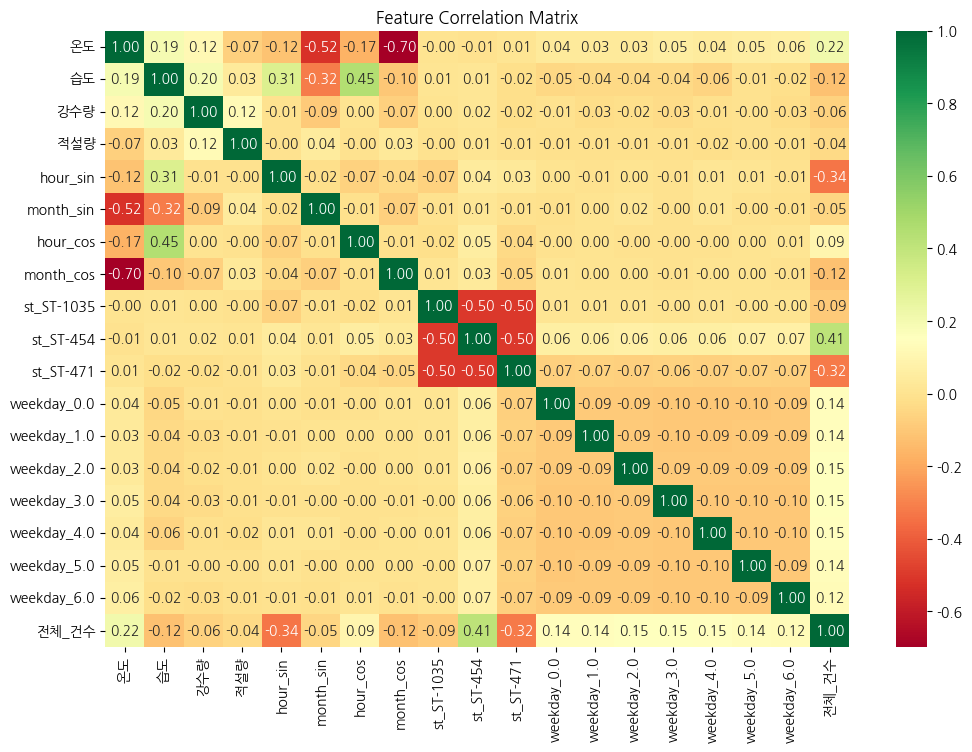

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# 분석에 사용할 변수들만 추출
corr_df = df_hourly[features + [target]]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

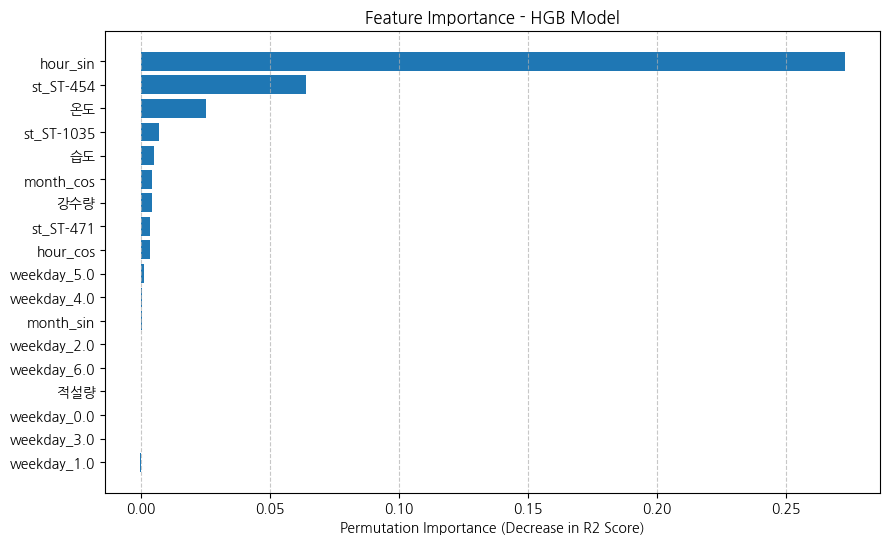

In [57]:
from sklearn.inspection import permutation_importance

# 테스트 데이터셋을 기준으로 측정합니다.
result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)

# 시각화를 위해 정렬
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in R2 Score)")
plt.title("Feature Importance - HGB Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()